In [1]:
import Pkg
Pkg.add("Kinbiont")
Pkg.add("CSV")
Pkg.add("Tables")
Pkg.add("Plots")
Pkg.add("StatsBase")


using Kinbiont
using CSV
using Tables
using StatsBase
using Plots

   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
    Updating `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  [bd369af6] + Tables v1.12.0
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utiliti

In this example we show how to fit a single curve from the dataset of E.coli + phages from ["Fast phage detection and quantification: An optical density-based approach"](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0216292) and the diauxic growth data from ["Diauxic lags explain unexpected coexistence in multi-resource environments"](https://www.embopress.org/doi/full/10.15252/msb.202110630).

We start importing the data of phages + E.coli, subtracting the blanks

In [2]:
blank_value= mean([0.0965,	0.0943,	0.0974, 0.0963,	0.0947,	0.0972,0.0964,	0.0943,	0.0957]);
path_to_data = string("../Diauxic_Phages//data/coli_phages/10^8cfu.csv");

data_matrix  = CSV.read(path_to_data, Tables.matrix);
data_OD = permutedims( [data_matrix[:,1]./60 data_matrix[:,12]] );
data_OD[2,:] = data_OD[2,:] .- blank_value;


We initialize the Kinbiont model with parameters bounds and guess. 

In [3]:
ub_dhpm_d =[ 10.1 , 10.7, 10.1  ,10.1];
lb_dhpm_d =[ 0.000000001 , 0.0000000010, 0.000000001  ,0.000000000001];
p_guess  = lb_dhpm_d .+ (ub_dhpm_d.- lb_dhpm_d)./2;

model = "HPM_3_death";


We fit

In [5]:
results_ODE_fit = Kinbiont.fitting_one_well_ODE_constrained(
    data_OD, 
    "test",
    "Coli_Phages",
    model,
    p_guess;
   lb = lb_dhpm_d,
   ub = ub_dhpm_d
);

We plot the fit:

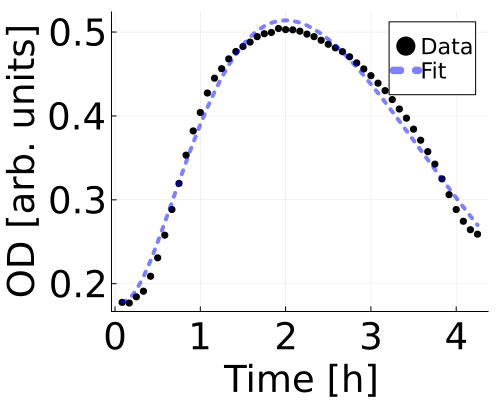

In [8]:

scatter(data_OD[1,:],data_OD[2,:], label="Data", xlabel="Time [h]", ylabel="OD [arb. units]", legend=:topleft,color =:black,markesize=10)
display(plot!(results_ODE_fit[4],results_ODE_fit[3],label=[ "Fit" nothing],line=4,xlabel="Time [h]", ylabel="OD [arb. units]",color=:blue,linewidth=8, size=(500, 400), legendposition=:topright, tickfontsize=25, labelfontsize=25, legendfontsize=15, linestyle=:dot,alpha=0.5))


Now we load the diauxic dataset, and we select one column to do the fit example.


In [21]:
data_1 = CSV.File("../Diauxic_Phages//data/diauxic/data_modified_1.csv", transpose=true, missingstring=nothing);
names_of_cols = propertynames(data_1);
data_temp = data_1[names_of_cols[1]];
times_data = convert(Vector{Float64}, data_temp)./(60*60);



data_OD = Matrix(transpose(hcat(times_data, data_1[names_of_cols[38]])));

We define the Kinbiont models, parameters guesses and bounds.

In [26]:

ub_exp = [2.3];
lb_exp = [00.00];

ub_logistic = [2.1, 0.9];
lb_logistic = [0.0001, 0.000001];

ub_alogistic = [2.1, 0.9, 10.0];
lb_alogistic = [0.0001, 0.000001, 0.001];

ub_hpm = [2.3, 0.8, 0.9];
lb_hpm = [0.0001, 0.000001, 0.001];


ub_hpm_exp = [2.1, 1.0];
lb_hpm_exp = [0.0001, 0.0000001];



list_of_models = ["HPM", "HPM_exp", "logistic", "exponential"];
list_ub_param = [ub_hpm, ub_hpm_exp, ub_logistic, ub_exp];
list_lb_param = [lb_hpm, lb_hpm_exp, lb_logistic, lb_exp];
list_guess = list_lb_param .+ (list_ub_param .- list_lb_param)./2;

We fit using 2 segments 

In [ ]:
seg_fitting = segmentation_ODE(
            data_OD, # dataset first row times second row OD
           "test", # name of the well
            "data_1", #label of the experiment
            list_of_models, # ode models to use
            list_guess,
            2;
            lb_param_array=list_lb_param, # lower bound param
            ub_param_array=list_ub_param, # upper bound param
            detect_number_cpd=false,
            fixed_cpd=false,
            type_of_detection="slinding_win",
            type_of_curve="deriv",
            pt_avg=3, # number of the point to generate intial condition
            smoothing=false, # the smoothing is done or not?           
            pt_smooth_derivative=8,
            win_size = 10
);



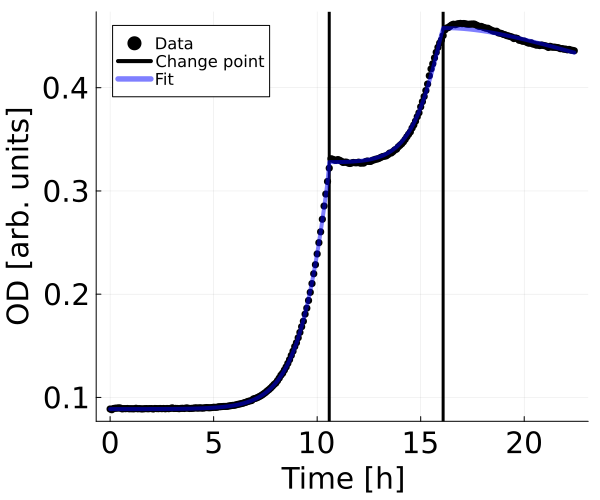

In [28]:
scatter(data_OD[1,:],data_OD[2,:], label="Data", xlabel="Time [h]", ylabel="OD [arb. units]", legend=:topleft,color =:black);
vline!(seg_fitting[5],label=[ "Change point" nothing],line=3,color=:black);
display(plot!(seg_fitting[4],seg_fitting[3],label=[ "Fit" nothing],line=4,xlabel="Time [h]", ylabel="OD [arb. units]",size = (600,500),markersize = 6,tickfontsize = 20,labelfontsize = 20,legendfontsize =11,alpha = 0.5,color =:blue))
